In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading both Jan & Feb 2026 months data

In [2]:
df_jan = pd.read_parquet('data/green_tripdata_2026-01.parquet')
df_feb = pd.read_parquet('data/green_tripdata_2026-02.parquet')

print("January shape:", df_jan.shape)
print("February shape:", df_feb.shape)

January shape: (40272, 21)
February shape: (37373, 21)


In [3]:
df_jan.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.7,...,1.5,7.5,0.0,NaN,1.0,45.20,1.0,1.0,2.75,0.75
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.0,...,0.0,10.2,0.0,NaN,1.0,61.20,1.0,2.0,0.00,0.00
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.5,...,1.5,2.0,0.0,NaN,1.0,46.00,1.0,1.0,0.00,0.00
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.8,...,1.5,0.0,0.0,NaN,1.0,25.05,2.0,1.0,2.75,0.00
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.1,...,0.5,0.0,0.0,NaN,1.0,21.60,2.0,1.0,0.00,0.00


In [4]:
df_jan.dtypes

VendorID                          int32
lpep_pickup_datetime     datetime64[us]
lpep_dropoff_datetime    datetime64[us]
store_and_fwd_flag               object
RatecodeID                      float64
PULocationID                      int32
DOLocationID                      int32
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee                       float64
improvement_surcharge           float64
total_amount                    float64
payment_type                    float64
trip_type                       float64
congestion_surcharge            float64
cbd_congestion_fee              float64
dtype: object

Creating the target variable (trip duration in minutes)

In [8]:
df_jan['duration'] = (df_jan['lpep_dropoff_datetime'] - df_jan['lpep_pickup_datetime']).dt.total_seconds()
df_jan['duration'] /= 60

print(df_jan['duration'].describe())

count    40272.000000
mean        20.075434
std         69.852105
min          0.000000
25%          8.100000
50%         12.883333
75%         20.050000
max       1439.800000
Name: duration, dtype: float64


In [9]:
df_jan

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,duration
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.70,...,7.50,0.00,NaN,1.0,45.20,1.0,1.0,2.75,0.75,27.300000
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.00,...,10.20,0.00,NaN,1.0,61.20,1.0,2.0,0.00,0.00,48.383333
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.50,...,2.00,0.00,NaN,1.0,46.00,1.0,1.0,0.00,0.00,21.300000
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.80,...,0.00,0.00,NaN,1.0,25.05,2.0,1.0,2.75,0.00,16.200000
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.10,...,0.00,0.00,NaN,1.0,21.60,2.0,1.0,0.00,0.00,18.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40267,2,2026-01-31 23:53:00,2026-02-01 00:08:00,None,NaN,25,228,NaN,2.57,17.98,...,3.90,0.00,NaN,1.0,23.38,NaN,NaN,NaN,0.00,15.000000
40268,2,2026-01-31 23:57:00,2026-02-01 00:07:00,None,NaN,223,7,NaN,1.58,14.25,...,3.94,0.00,NaN,1.0,19.69,NaN,NaN,NaN,0.00,10.000000
40269,6,2026-01-31 23:21:55,2026-01-31 23:47:54,None,NaN,256,228,NaN,8.17,3.00,...,0.00,0.00,NaN,0.3,26.02,NaN,NaN,NaN,0.00,25.983333
40270,2,2026-01-31 23:43:00,2026-02-01 00:08:00,None,NaN,66,186,NaN,6.27,30.89,...,7.18,0.00,NaN,1.0,43.07,NaN,NaN,NaN,0.75,25.000000


In [13]:
df_jan['duration'].describe(percentiles = [0.95, 0.98, 0.99])

count    40272.000000
mean        20.075434
std         69.852105
min          0.000000
50%         12.883333
95%         44.016667
98%         64.286000
99%         82.886500
max       1439.800000
Name: duration, dtype: float64

Plotting distribution

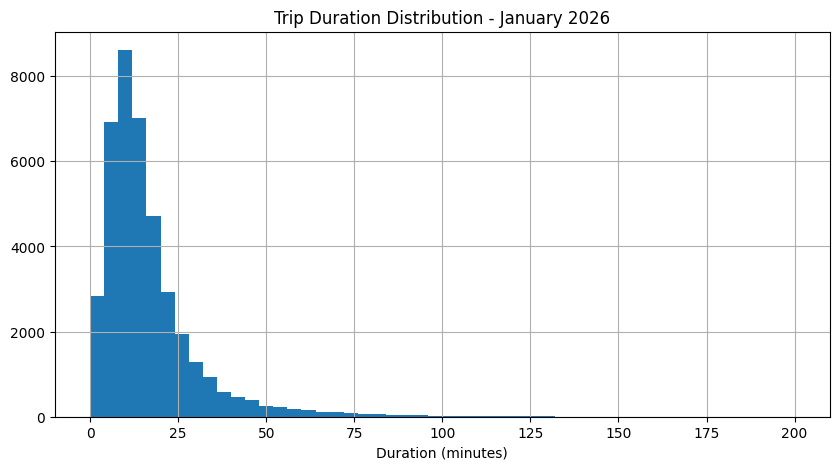

In [14]:
df_jan['duration'].hist(bins=50, figsize=(10,5), range=(0,200))
plt.xlabel('Duration (minutes)')
plt.title('Trip Duration Distribution - January 2026')
plt.show()

In [15]:
df_jan_filtered = df_jan[(df_jan['duration'] >= 1) & (df_jan['duration'] <= 60)]

print(f"Original:  {len(df_jan)} rows")
print(f"Filtered:  {len(df_jan_filtered)} rows")
print(f"Kept: {len(df_jan_filtered)/len(df_jan)*100:.2f}%")

Original:  40272 rows
Filtered:  38088 rows
Kept: 94.58%


In [16]:
df_jan_filtered['duration'].describe(percentiles = [0.95, 0.98, 0.99])

count    38088.000000
mean        15.581492
std         10.310362
min          1.000000
50%         12.950000
95%         37.160833
98%         46.975333
99%         52.435500
max         60.000000
Name: duration, dtype: float64

In [17]:
print("Nulls:\n", df_jan_filtered.isnull().sum())
print("\nDuplicates:", df_jan_filtered.duplicated().sum())

Nulls:
 VendorID                     0
lpep_pickup_datetime         0
lpep_dropoff_datetime        0
store_and_fwd_flag        4732
RatecodeID                4732
PULocationID                 0
DOLocationID                 0
passenger_count           4732
trip_distance                0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
ehail_fee                38088
improvement_surcharge        0
total_amount                 0
payment_type              4732
trip_type                 4732
congestion_surcharge      4732
cbd_congestion_fee           0
duration                     0
dtype: int64

Duplicates: 0


Same for February

In [18]:
df_feb['duration'] = (df_feb['lpep_dropoff_datetime'] - df_feb['lpep_pickup_datetime']).dt.total_seconds()
df_feb['duration'] /= 60

print(df_feb['duration'].describe())

count    37373.000000
mean        20.707001
std         72.301272
min        -10.183333
25%          8.433333
50%         13.316667
75%         20.616667
max       1438.316667
Name: duration, dtype: float64


In [19]:
df_feb['duration'].describe(percentiles = [0.95, 0.98, 0.99])

count    37373.000000
mean        20.707001
std         72.301272
min        -10.183333
50%         13.316667
95%         43.866667
98%         63.611333
99%         82.640000
max       1438.316667
Name: duration, dtype: float64

In [21]:
df_feb_filtered = df_feb[(df_feb['duration'] >= 1) & (df_feb['duration'] <= 60)]

print(f"Original:  {len(df_feb)} rows")
print(f"Filtered:  {len(df_feb_filtered)} rows")
print(f"Kept: {len(df_feb_filtered)/len(df_feb)*100:.2f}%")

Original:  37373 rows
Filtered:  35319 rows
Kept: 94.50%


In [23]:
df_feb_filtered['duration'].describe(percentiles = [0.95, 0.98, 0.99])

count    35319.000000
mean        16.003446
std         10.365068
min          1.000000
50%         13.400000
95%         37.600000
98%         47.150000
99%         52.491000
max         60.000000
Name: duration, dtype: float64

 Selecting features and converting to string (categorical)

In [24]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df_jan_filtered[categorical] = df_jan_filtered[categorical].astype(str)
df_feb_filtered[categorical] = df_feb_filtered[categorical].astype(str)

/tmp/ipykernel_3348/2035294277.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_jan_filtered[categorical] = df_jan_filtered[categorical].astype(str)
/tmp/ipykernel_3348/2035294277.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feb_filtered[categorical] = df_feb_filtered[categorical].astype(str)


 Prepareing training and validation sets

In [25]:
train_dicts = df_jan_filtered[categorical + numerical].to_dict(orient='records')
val_dicts = df_feb_filtered[categorical + numerical].to_dict(orient='records')

y_train = df_jan_filtered['duration'].values
y_val = df_feb_filtered['duration'].values

print("Train size:", len(train_dicts))
print("Val size:", len(val_dicts))

Train size: 38088
Val size: 35319


Vectorizing using DictVectorizer

In [26]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (38088, 472)
X_val shape: (35319, 472)


Training the model

In [27]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

print("Model trained!")

Model trained!


Evaluating on training and validation sets

In [28]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred_train = lr.predict(X_train)
y_pred_val = lr.predict(X_val)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))

print(f"RMSE on Train: {rmse_train:.2f} mins")
print(f"RMSE on Val:   {rmse_val:.2f} mins")

RMSE on Train: 8.05 mins
RMSE on Val:   8.34 mins


Saving model and vectorizer

In [29]:
import pickle
import os

os.makedirs('models', exist_ok=True)

with open('models/lin_reg.bin', 'wb') as f:
    pickle.dump((dv, lr), f)

print("Model saved to models/lin_reg.bin")

Model saved to models/lin_reg.bin
